<a href="https://colab.research.google.com/github/arun-arunisto/ComputerVisionEngineering/blob/todo/GettingStartedWithDiffusersPart1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Getting started with Diffusers for Text-to-Image


In [1]:
#installing required packages Diffusers and accelerate
!pip install Diffusers
!pip install accelerate

After installing the packages going to import the necessary packages for this project


In [2]:
import tqdm
import torch
import PIL
import PIL.Image
import numpy as np
import diffusers
from PIL import Image
from diffusers import UNet2DModel
from diffusers import AutoPipelineForText2Image
from diffusers import DDPMPipeline
from diffusers import DDPMScheduler

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Adjust torch_dtype based on the device
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

For stable diffusion v1.5 using `runwayml/stable-diffusion-v1-5`

In [5]:
#loading pipeline
pipeline = AutoPipelineForText2Image.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch_dtype,
    variant="fp16" if torch.cuda.is_available() else None,  # Variant only for GPU
).to(device)

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

scheduler/scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

(…)ature_extractor/preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

text_encoder/config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

unet/config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

vae/config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

After setting up the pipeline trying to create an image using text

  0%|          | 0/50 [00:00<?, ?it/s]

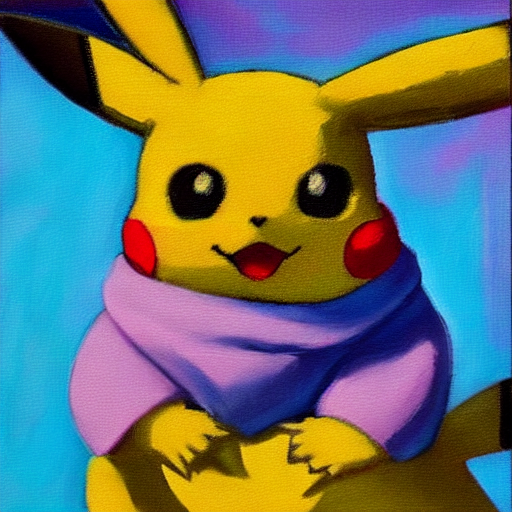

In [6]:
#generating image
image = pipeline(
	"impressionist oil painting of pikachu, backlight, centered composition, masterpiece, photorealistic, 8k"
).images[0]
image

  0%|          | 0/50 [00:00<?, ?it/s]

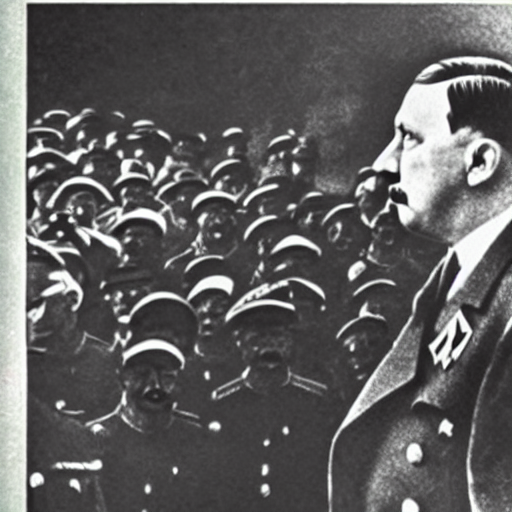

In [7]:
#generating image
image = pipeline(
	"adolf hitler in india"
).images[0]
image

For stable diffusion XL, using `stabilityai/stable-diffusion-xl-base-1.0`

In [8]:
pipeline = AutoPipelineForText2Image.from_pretrained(
	"stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch_dtype, variant="fp16" if torch.cuda.is_available() else None,
).to(device)

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

scheduler/scheduler_config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

text_encoder_2/config.json:   0%|          | 0.00/575 [00:00<?, ?B/s]

text_encoder/config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/10.3G [00:00<?, ?B/s]

vae/config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

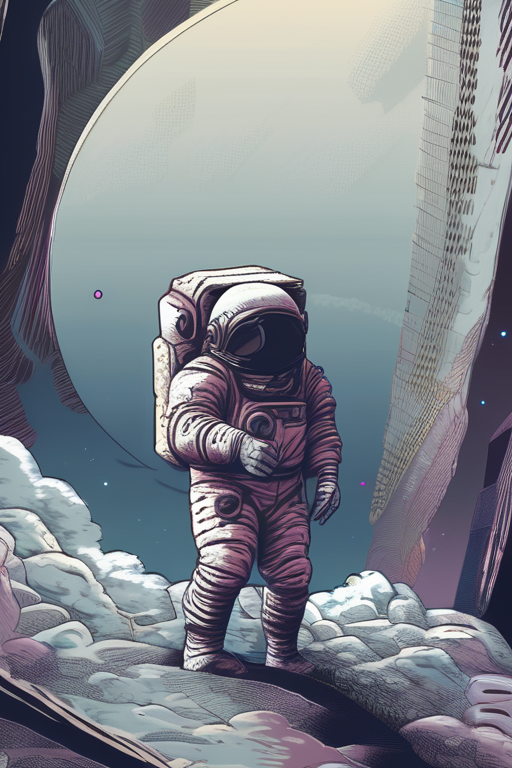

In [9]:
prompt = "Astronaut in a 2800 New York, cold color palette, muted colors, detailed, 8k"
image = pipeline(prompt = prompt,
                 height=768,
                 width=512,
                 ).images[0]
image

And for Kandinsky 2.2 going to use `kandinsky-community/kandinsky-2-2-decoder`

In [10]:
pipeline = AutoPipelineForText2Image.from_pretrained(
	"kandinsky-community/kandinsky-2-2-decoder", torch_dtype=torch_dtype, variant="fp16" if torch.cuda.is_available() else None,
).to(device)

model_index.json:   0%|          | 0.00/250 [00:00<?, ?B/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

movq/config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

unet/config.json:   0%|          | 0.00/1.67k [00:00<?, ?B/s]

scheduler/scheduler_config.json:   0%|          | 0.00/317 [00:00<?, ?B/s]

...

tokenizer/special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer/merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer/vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

tokenizer/tokenizer_config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/diffusers/pipelines/kandinsky2_2/pipeline_kandinsky2_2.py:202: FutureWarning: `callback_steps` is deprecated and will be removed in version 1.0.0. Passing `callback_steps` as an input argument to `__call__` is deprecated, consider use `callback_on_step_end`
  deprecate(


  0%|          | 0/70 [00:00<?, ?it/s]

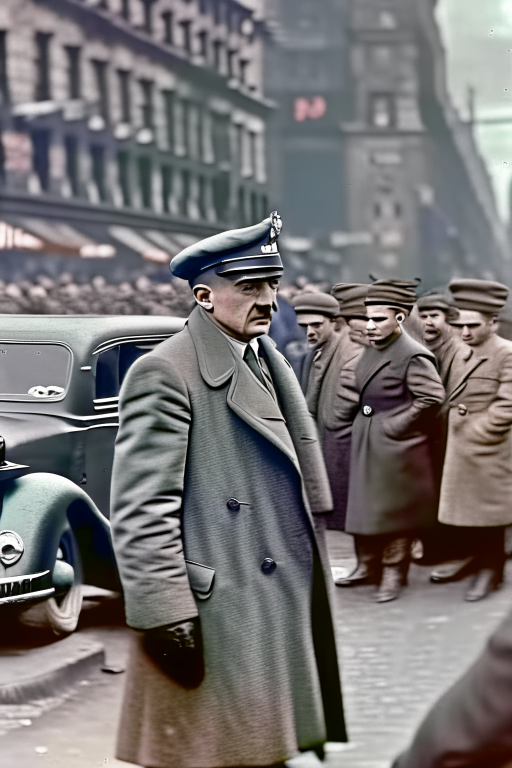

In [11]:
prompt = "Adolf hitler in New York at 1940, cold color palette, muted colors, detailed, 8k"
image = pipeline(prompt = prompt,
                 height=768,
                 width=512,
                 num_inference_steps=70,
                 guidance_scale=10.5,
                 ).images[0]
image

## DDPM Pipeline
***Denoising Diffusion Probabilistic Models*** pipeline to demonstrate we're using the `google/ddpm-celebahq-256` model

In [12]:
ddpm_pipeline = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
ddpm_pipeline.to(device)

model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.31.0",
  "_name_or_path": "google/ddpm-celebahq-256",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

To generate an image, we simply run the pipeline and don’t even need to give it any input. It will generate a random initial noise sample and then iterate the diffusion process.

The pipeline returns as output a dictionary with a generated sample of interest.

  0%|          | 0/1000 [00:00<?, ?it/s]

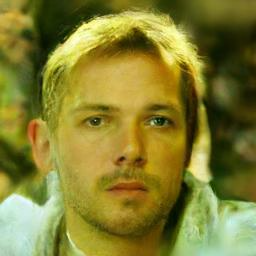

In [13]:
images = ddpm_pipeline().images
images[0]

Let’s break down the pipeline and take a look at what’s happening under the hood.

In [14]:
repo_id = "google/ddpm-celebahq-256"
scheduler = DDPMScheduler.from_pretrained(repo_id)
model = UNet2DModel.from_pretrained(repo_id).to(device)

An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [15]:
model

UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0-1): 2 x DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Con

In [16]:
scheduler.config

FrozenDict([('num_train_timesteps', 1000),
            ('beta_start', 0.0001),
            ('beta_end', 0.02),
            ('beta_schedule', 'linear'),
            ('trained_betas', None),
            ('variance_type', 'fixed_small'),
            ('clip_sample', True),
            ('prediction_type', 'epsilon'),
            ('thresholding', False),
            ('dynamic_thresholding_ratio', 0.995),
            ('clip_sample_range', 1.0),
            ('sample_max_value', 1.0),
            ('timestep_spacing', 'leading'),
            ('steps_offset', 0),
            ('rescale_betas_zero_snr', False),
            ('_use_default_values',
             ['steps_offset',
              'sample_max_value',
              'prediction_type',
              'timestep_spacing',
              'thresholding',
              'clip_sample_range',
              'dynamic_thresholding_ratio',
              'rescale_betas_zero_snr']),
            ('_class_name', 'DDPMScheduler'),
            ('_diffusers_versi

In [17]:
torch.manual_seed(666)
noisy_sample = torch.randn(
    1, model.config.in_channels, model.config.sample_size, model.config.sample_size
).to(device)
noisy_sample.shape

torch.Size([1, 3, 256, 256])

In [18]:
with torch.no_grad():
    noisy_residual = model(sample=noisy_sample, timestep=2).sample

In [19]:
less_noisy_sample = scheduler.step(
    model_output=noisy_residual, timestep=2, sample=noisy_sample
).prev_sample
less_noisy_sample.shape

torch.Size([1, 3, 256, 256])

We can see that the computed sample has the same shape as the model input, meaning that you are ready to pass it to the model again in the next step. Let’s now bring it all together and actually define the denoising loop. This loop prints out the (less and less) noisy samples along the way for better visualization in the denoising loop.

In [20]:
def display_sample(sample, i):
    image_processed = sample.cpu().permute(0, 2, 3, 1)
    image_processed = (image_processed + 1.0) * 127.5
    image_processed = image_processed.numpy().astype(np.uint8)
    image_pil = PIL.Image.fromarray(image_processed[0])
    display(f"Image at step {i}")
    display(image_pil)

 10%|▉         | 99/1000 [17:43<2:35:36, 10.36s/it]

'Image at step 100'

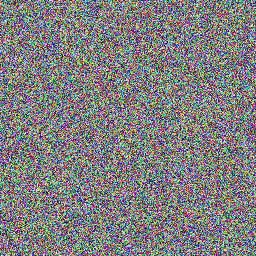

 20%|█▉        | 199/1000 [35:39<2:20:13, 10.50s/it]

'Image at step 200'

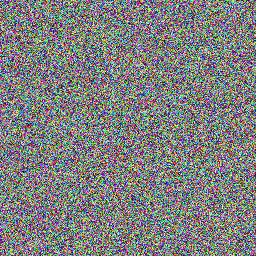

 30%|██▉       | 299/1000 [53:40<2:08:31, 11.00s/it]

'Image at step 300'

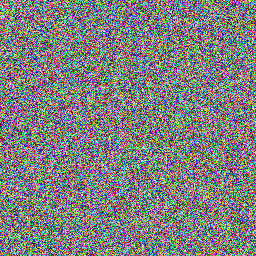

 40%|███▉      | 399/1000 [1:11:49<1:50:40, 11.05s/it]

'Image at step 400'

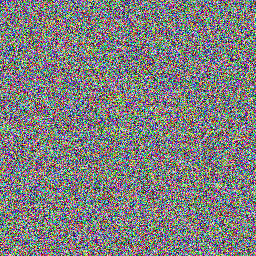

 50%|████▉     | 499/1000 [1:29:46<1:29:11, 10.68s/it]

'Image at step 500'

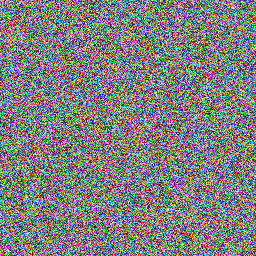

 60%|█████▉    | 599/1000 [1:47:38<1:13:18, 10.97s/it]

'Image at step 600'

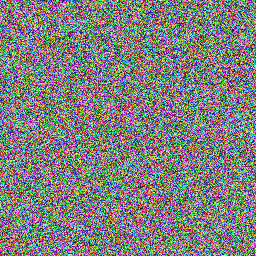

 70%|██████▉   | 699/1000 [2:05:27<52:42, 10.51s/it]

'Image at step 700'

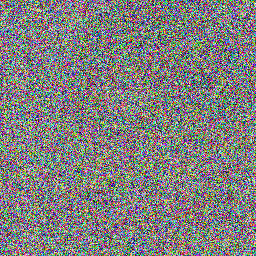

 80%|███████▉  | 799/1000 [2:23:05<35:19, 10.54s/it]

'Image at step 800'

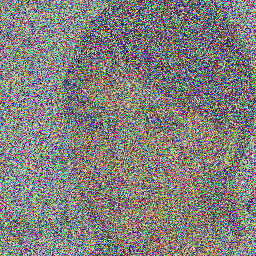

 90%|████████▉ | 899/1000 [2:40:48<17:19, 10.29s/it]

'Image at step 900'

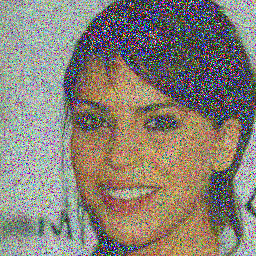

100%|█████████▉| 999/1000 [2:58:26<00:10, 10.66s/it]

'Image at step 1000'

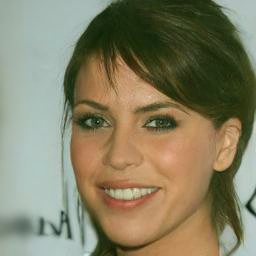

100%|██████████| 1000/1000 [2:58:36<00:00, 10.72s/it]


In [21]:
sample = noisy_sample
for i, t in enumerate(tqdm.tqdm(scheduler.timesteps)):
  # predict the noise residual
  with torch.no_grad():
      residual = model(sample, t).sample
  # compute the less noisy image
  # by removing the predicted noise
  # residual at the current timestep
  sample = scheduler.step(residual, t, sample).prev_sample
  # visualize the image
  if (i + 1) % 100 == 0:
      display_sample(sample, i + 1)

This notebook provided a starting point for using the Hugging Face Diffusers library for text-to-image generation. We covered the essentials of diffusion models, setting up the environment, and the components of the diffusers library. Additionally, we delved into the various parameters of an Automatic Text-to-Image Pipeline.

We also dissected the DDPM pipeline from the diffusers library and hand-crafted a custom denoising loop to see how all components come together to create an image from a noisy vector conditioned on a text prompt.